# 🧠 Stroke MRI: Section 1 — Single-Modality Quality Control & Geometry Inspection

**Research Focus:**
Before performing multi-modal registration, lesion segmentation, or radiologic-pathologic correlation, a neuroimaging researcher or clinician must rigorously audit the physical geometry, coordinate conventions, and intensity fidelity of each acquisition.

This notebook demonstrates the foundational Section 1 QC workflow using `mri_utils.py`:
1. **Geometry & Physical Extent**: Inspecting shapes, voxel sizes, affines, orientations (`LPS`, `PSR`, `SPR`), and physical millimeter bounds.
2. **Multiplanar Slice Visualization**: Confirming anatomical views (superior up, patient right on left) without arbitrary transpositions.
3. **Intensity Traps & Artifact Detection**: Automatically identifying non-zero background floors from NIfTI intercept scaling (`scl_inter`) and upper-boundary ceiling saturation (uint8 clipping).
4. **Visual Intensity Profiling**: Examining full-volume log-histograms, tissue-specific distributions, and empirical cumulative density functions.
5. **Brain Parenchyma Masking**: Generating robust brain masks with hole filling and largest connected component retention, reporting volumetric measurements in mL.
6. **Consolidated Researcher QC Summary**: Producing an interpretable, cross-volume diagnostic table.

In [24]:
import sys
from pathlib import Path
if ".." not in sys.path:
    sys.path.append("..")

# Data directory: notebooks/data or stroke_notebooks/data
DATA_DIR = Path("data") if Path("data").is_dir() else Path("../data") if Path("../data").is_dir() else Path(".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import nibabel as nib

import importlib
import mri_utils as mu
importlib.reload(mu)

# Representative MRI volumes capturing diverse clinical & ex-vivo acquisitions:
# 1. DWI-11: Clinical 22-slice acquisition (LPS orientation, ~10° oblique tilt, uint16)
# 2. iv11_DWI: High-resolution in-vivo volume (PSR orientation, uint8 scaled with intercept trap)
# 3. iv16_DWI: High-resolution in-vivo volume (PSR orientation, uint8 ceiling at 196.8)
# 4. 16dpm_DWI_reg: Ex-vivo reference space registered volume (SPR orientation, float32)
sample_files = {
    "DWI-11 (Clinical LPS)": str(DATA_DIR / "DWI-11.nii"),
    "iv11_DWI (In-Vivo PSR)": str(DATA_DIR / "iv11_DWI.nii.gz"),
    "iv16_DWI (In-Vivo PSR)": str(DATA_DIR / "iv16_DWI.nii.gz"),
    "16dpm_DWI_reg (Ex-Vivo SPR)": str(DATA_DIR / "16dpm_DWI_regto_exvivo_cropped.nii.gz"),
}

vols = {name: mu.load_mri(fn) for name, fn in sample_files.items()}
print(f"Loaded {len(vols)} representative volumes into memory from {DATA_DIR}.")


Loaded 4 representative volumes into memory.


## 1.1 Geometry & Physical Extent Inspection
Comparing acquisition matrices, voxel resolutions, orientation codes, and physical world bounding boxes (RAS mm).

In [25]:
geometry_rows = []
for name, m in vols.items():
    info = mu.inspect_mri(m)["value"].to_dict()
    info["acquisition"] = name
    geometry_rows.append(info)

geom_df = pd.DataFrame(geometry_rows).set_index("acquisition")
display(geom_df[[
    "file", "shape (voxels)", "raw / loaded dtype", "voxel size (mm)",
    "orientation (axcodes)", "max voxel-axis tilt (deg)",
    "field of view (mm)", "physical extent (mm)"
]])

,file,shape (voxels),raw / loaded dtype,voxel size (mm),orientation (axcodes),max voxel-axis tilt (deg),field of view (mm),physical extent (mm)
acquisition,,,,,,,,
DWI-11 (Clinical LPS),DWI-11.nii,"(192, 192, 22)",uint16 / float32,"(1.198, 1.198, 5.5)",LPS,9.92,"(246.1, 255.0, 163.8)","X[-123.3, 122.8] Y[-129.4, 125.6] Z[-78.5, 85.3]"
iv11_DWI (In-Vivo PSR),iv11_DWI.nii.gz,"(377, 211, 238)",uint8 / float32,"(0.488, 0.488, 0.7)",PSR,0.00,"(165.9, 183.6, 102.5)","X[0.0, 165.9] Y[-202.6, -19.0] Z[85.0, 187.5]"
iv16_DWI (In-Vivo PSR),iv16_DWI.nii.gz,"(377, 211, 238)",uint8 / float32,"(0.488, 0.488, 0.7)",PSR,0.00,"(165.9, 183.6, 102.5)","X[0.0, 165.9] Y[-202.6, -19.0] Z[85.0, 187.5]"
16dpm_DWI_reg (Ex-Vivo SPR),16dpm_DWI_regto_exvivo_cropped.nii.gz,"(512, 512, 78)",float32 / float32,"(0.48, 0.48, 2.2)",SPR,0.00,"(169.4, 245.3, 245.3)","X[0.0, 169.4] Y[-245.3, 0.0] Z[0.0, 245.3]"


## 1.2 Multiplanar Orthogonal Slice Verification
Verifying that `show_mri` respects NIfTI affine direction cosines:
- Anatomical conventions are enforced: **Superior is up**, and **patient Right is on the viewer's left**.
- Slice aspect ratios are preserved using millimeter voxel zooms, ensuring oblique volumes (like `DWI-11` with a 9.9° tilt) are displayed without geometric distortion.

=== DWI-11 (Clinical LPS) ===


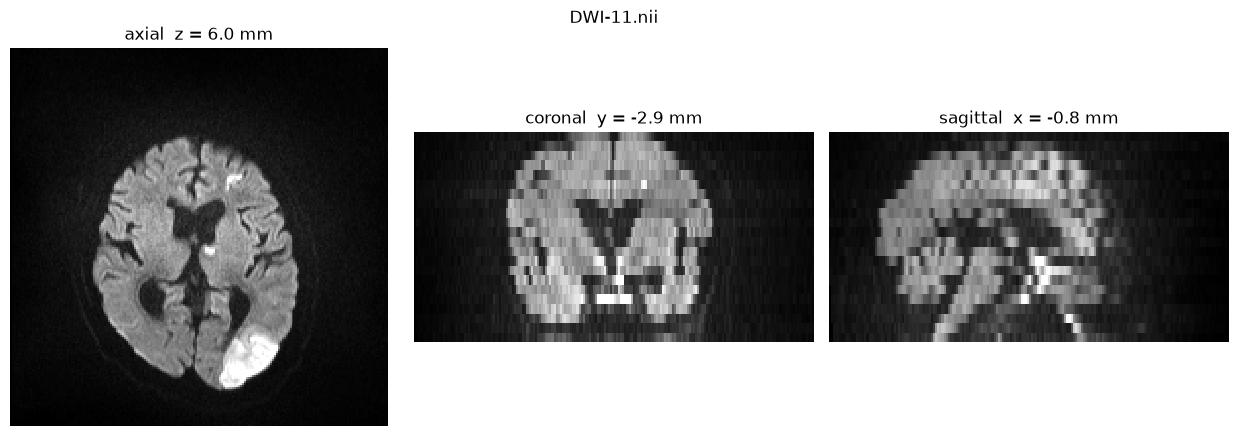

=== iv11_DWI (In-Vivo PSR) ===


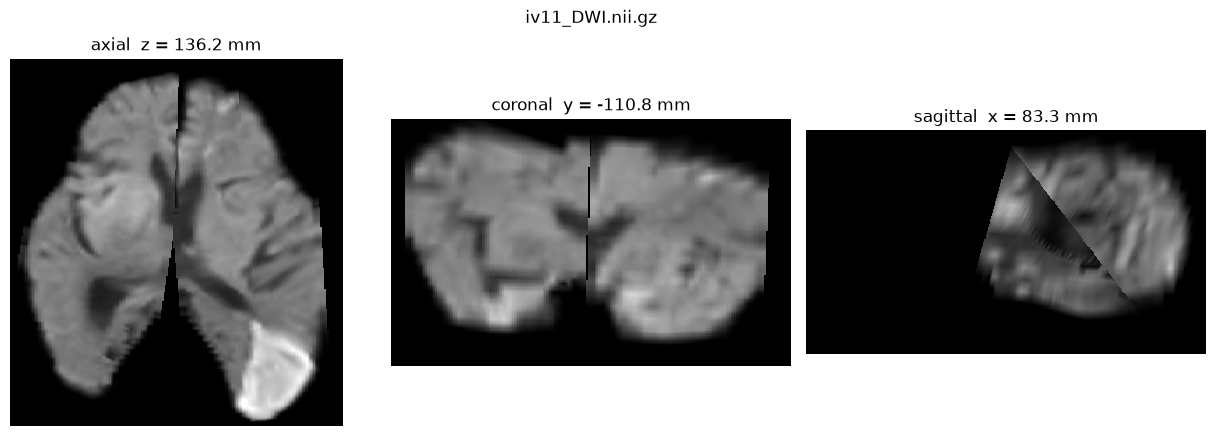

=== iv16_DWI (In-Vivo PSR) ===


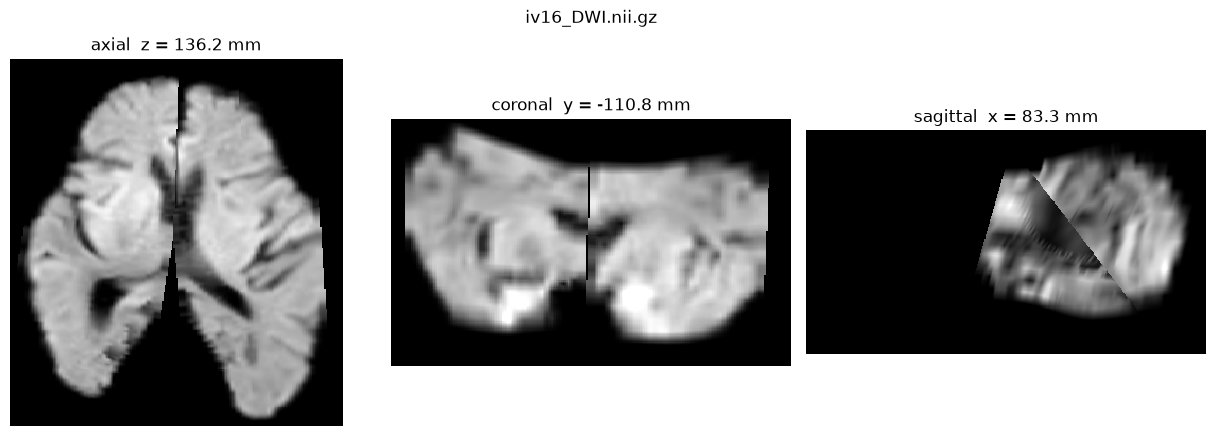

=== 16dpm_DWI_reg (Ex-Vivo SPR) ===


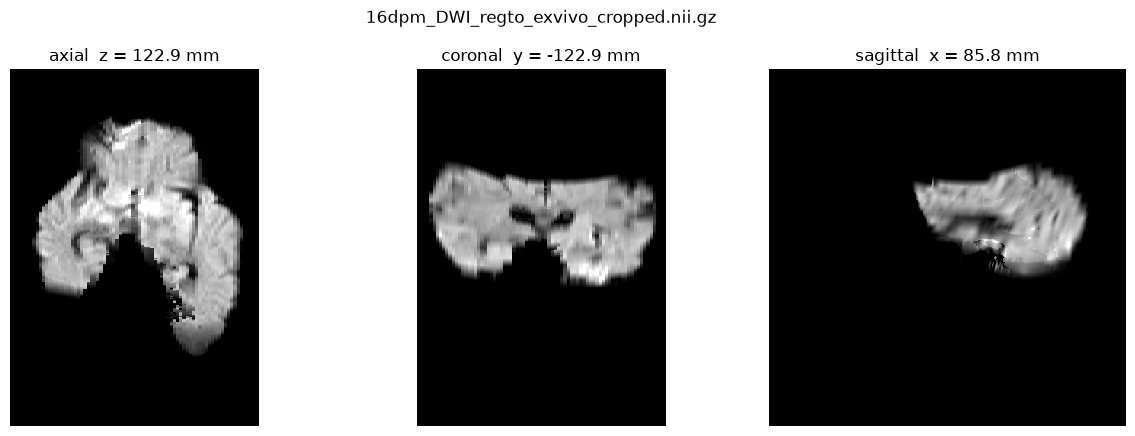

In [26]:
for name, m in vols.items():
    print(f"=== {name} ===")
    fig = mu.show_mri(m)
    plt.show()

## 1.3 Intensity Quality Control & Artifact Detection
Evaluating the data for common neuroimaging traps:
1. **Background Floor Trap (`bg_trap_flag`)**: In `iv11_DWI` and `iv16_DWI`, the NIfTI header defines a non-zero intercept (`scl_inter ≈ 0.0039` and `0.0010`). Raw zero voxels scale to small positive floats, meaning naive `data > 0` checks misclassify 60%+ of the grid (empty air) as tissue foreground.
2. **Ceiling Saturation (`clipping_flag`)**: High-intensity stroke lesions on raw uint8 acquisitions can saturate at the 255 ceiling (e.g. 40,896 voxels in `iv11_DWI`), artificially compressing dynamic range at the core.

In [27]:
intensity_rows = [mu.intensity_qc(m) for m in vols.values()]
intensity_df = pd.DataFrame(intensity_rows).set_index("file")
display(intensity_df[[
    "modality", "min", "median", "max",
    "zero_pct", "near_min_pct", "ceiling_pct",
    "bg_trap_flag", "clipping_flag"
]])

,modality,min,median,max,zero_pct,near_min_pct,ceiling_pct,bg_trap_flag,clipping_flag
file,,,,,,,,,
DWI-11.nii,DWI,0.000000,17.000000,947.000000,0.0072,0.0072,0.0000,False,False
iv11_DWI.nii.gz,DWI,0.003883,0.003883,258.522186,0.0000,0.5963,0.0022,True,True
iv16_DWI.nii.gz,DWI,0.001048,0.001048,196.834274,0.0000,0.6285,0.0020,True,True
16dpm_DWI_regto_exvivo_cropped.nii.gz,DWI,0.000000,0.000000,441.457550,0.8902,0.8902,0.0000,False,False


## 1.4 Visual Intensity Profiling
Generating three-panel visual audits using `plot_intensity_qc`:
- **Panel 1 (Full Volume Log Histogram)**: Exposes background noise floor peaks and saturation spikes at the ceiling.
- **Panel 2 (Tissue Range)**: Zooms into brain parenchyma intensities, marking the median and interquartile range (IQR).
- **Panel 3 (Empirical CDF)**: Shows the cumulative percentile curve.

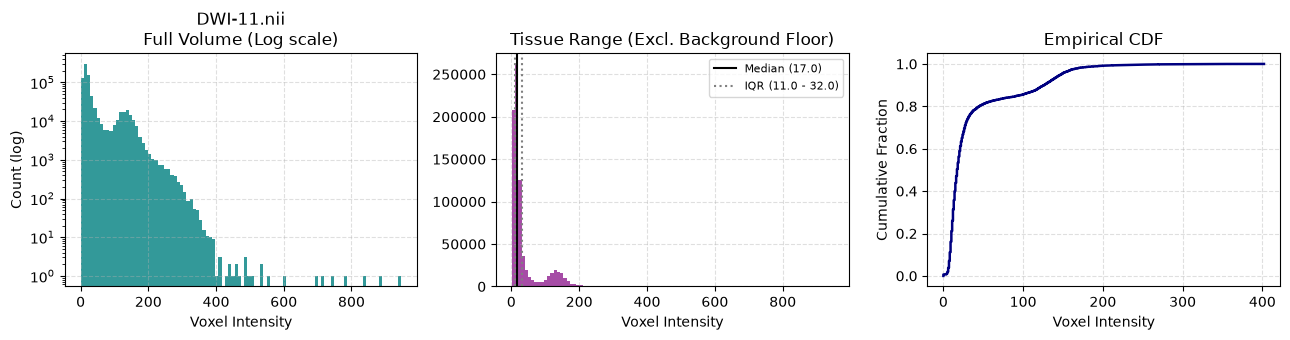

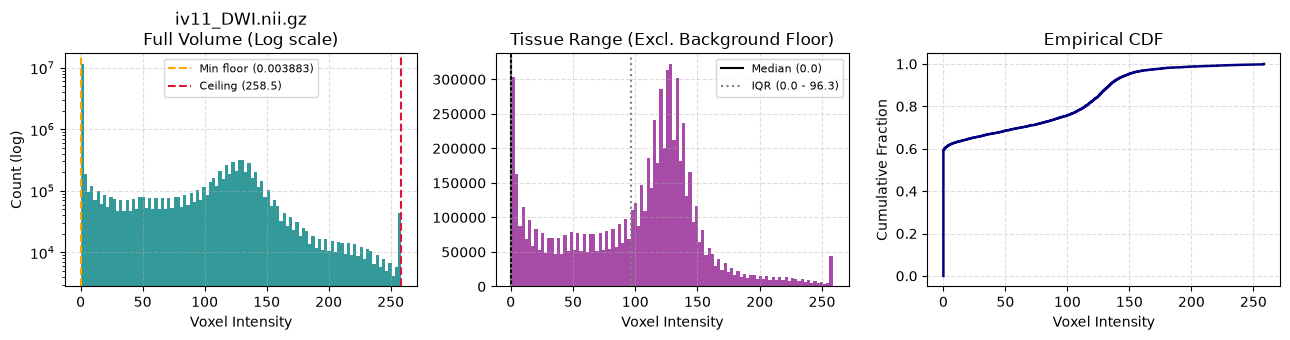

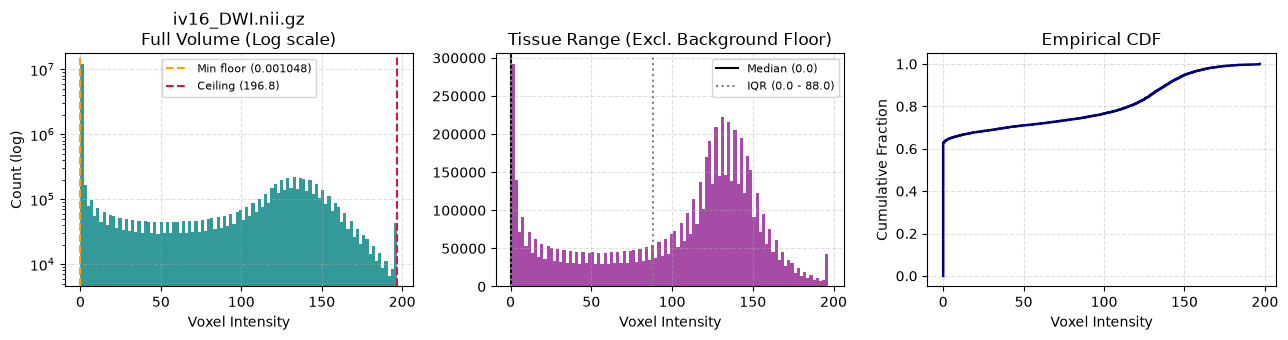

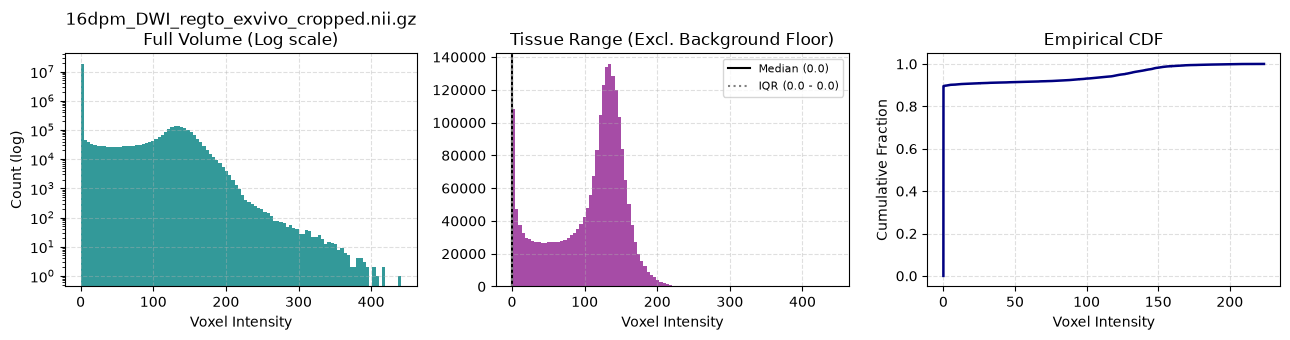

In [28]:
for name, m in vols.items():
    fig = mu.plot_intensity_qc(m)
    plt.show()

## 1.5 Robust Brain Parenchyma Masking
Using `brain_mask` (adaptive Otsu thresholding with background-floor rejection, hole filling, and largest connected component selection) and `mask_stats`:
- Confirms total estimated brain volume in mL.
- Computes centroid RAS coordinates and spatial bounding boxes.
- Displays multiplanar contour overlays.

,file,voxels,volume_mL,grid_fraction,centroid_RAS_mm,bbox_RAS_mm
acquisition,,,,,,
DWI-11 (Clinical LPS),DWI-11.nii,130563,1030.47,0.1610,"(-0.1, -20.1, 2.7)","{'x': (-62.9, 66.8), 'y': (-100.1, 67.8), 'z':..."
iv11_DWI (In-Vivo PSR),iv11_DWI.nii.gz,5126229,855.53,0.2708,"(81.8, -108.5, 142.4)","{'x': (7.7, 162.4), 'y': (-200.7, -27.8), 'z':..."
iv16_DWI (In-Vivo PSR),iv16_DWI.nii.gz,4868710,812.55,0.2572,"(82.4, -108.2, 140.9)","{'x': (7.7, 163.1), 'y': (-198.7, -28.3), 'z':..."
16dpm_DWI_reg (Ex-Vivo SPR),16dpm_DWI_regto_exvivo_cropped.nii.gz,1590803,806.35,0.0778,"(82.5, -108.1, 140.9)","{'x': (6.6, 160.6), 'y': (-199.2, -28.3), 'z':..."


Brain Mask Overlay: DWI-11 (Clinical LPS)


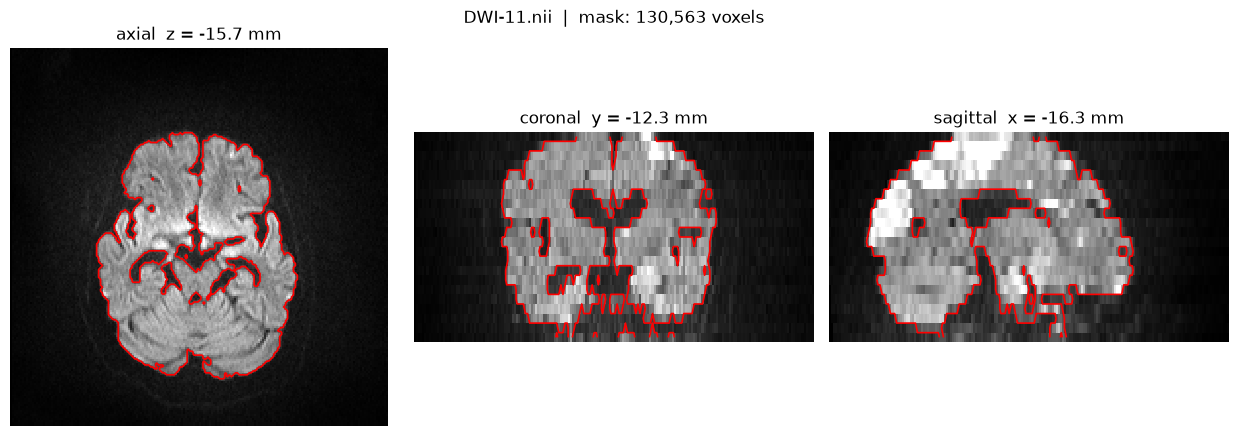

Brain Mask Overlay: iv11_DWI (In-Vivo PSR)


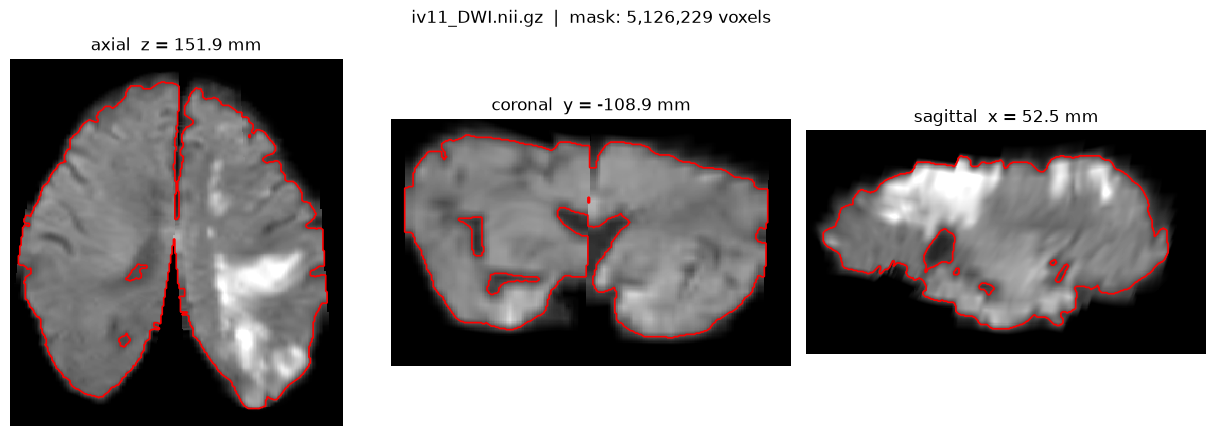

Brain Mask Overlay: iv16_DWI (In-Vivo PSR)


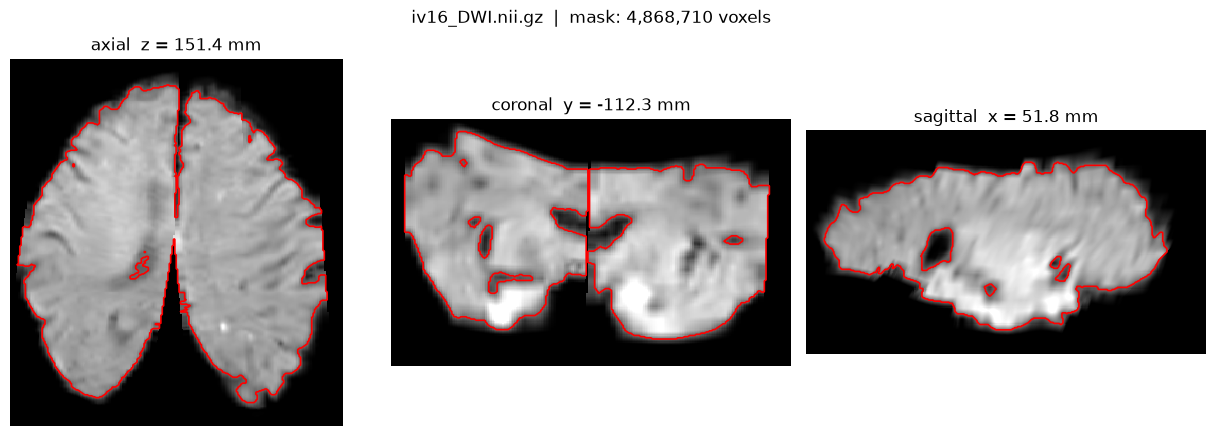

Brain Mask Overlay: 16dpm_DWI_reg (Ex-Vivo SPR)


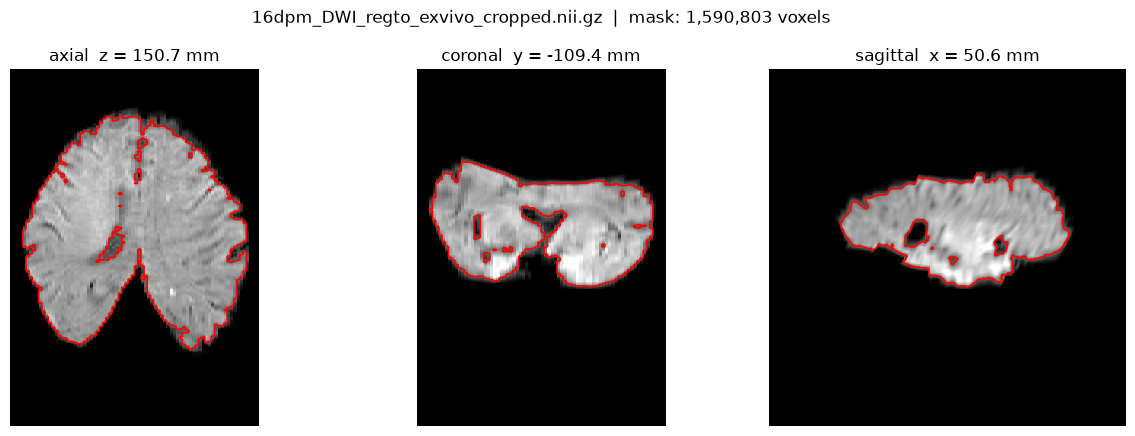

In [29]:
brain_masks = {}
mask_summary_rows = []

for name, m in vols.items():
    bm = mu.brain_mask(m)
    brain_masks[name] = bm
    stats = mu.mask_stats(bm, m)
    stats["acquisition"] = name
    stats["file"] = m.path.name
    mask_summary_rows.append(stats)

mask_df = pd.DataFrame(mask_summary_rows).set_index("acquisition")
display(mask_df[[
    "file", "voxels", "volume_mL", "grid_fraction", "centroid_RAS_mm", "bbox_RAS_mm"
]])

# Visualize brain mask contour overlays
for name, m in vols.items():
    print(f"Brain Mask Overlay: {name}")
    fig = mu.show_mri(m, mask=brain_masks[name])
    plt.show()

## 1.6 Consolidated Researcher / Clinician QC Summary
A compact tabular overview of all audited single-modality volumes generated via `qc_summary`.

In [30]:
summary_table = mu.qc_summary(list(vols.values()))
display(summary_table)

,file,modality,raw_dtype,shape,voxel_mm,orientation,fov_mm,min,median,max,near_min%,bg_trap,clipping
0,DWI-11.nii,DWI,uint16,"(192, 192, 22)","(1.2, 1.2, 5.5)",LPS,"(246.1, 255.0, 163.8)",0.000,17.0,947.0,0.7%,False,False
1,iv11_DWI.nii.gz,DWI,uint8,"(377, 211, 238)","(0.49, 0.49, 0.7)",PSR,"(165.9, 183.6, 102.5)",0.004,0.0,258.5,59.6%,True,True
2,iv16_DWI.nii.gz,DWI,uint8,"(377, 211, 238)","(0.49, 0.49, 0.7)",PSR,"(165.9, 183.6, 102.5)",0.001,0.0,196.8,62.8%,True,True
3,16dpm_DWI_regto_exvivo_cropped.nii.gz,DWI,float32,"(512, 512, 78)","(0.48, 0.48, 2.2)",SPR,"(169.4, 245.3, 245.3)",0.000,0.0,441.5,89.0%,False,False


### Section 1 QC Findings & Methodological Notes

| Observation | Finding & Scientific Implication |
|---|---|
| **Orientation Heterogeneity** | The repository contains three distinct coordinate conventions: `LPS` (`DWI-11` clinical scan), `PSR` (`iv11` / `iv16` in-vivo scans), and `SPR` (`16dpm_reg` ex-vivo space). Direct array operations across scans are strictly invalid; all cross-volume spatial comparisons must be affine-transformed. |
| **Oblique Gantry Tilt** | `DWI-11` exhibits a 9.92° tilt between voxel axes and patient world axes. Slice extraction requires direction-cosine rotation rather than simple 2D indexing. |
| **Background Intercept Trap** | `iv11_DWI` and `iv16_DWI` have non-zero intercepts (`0.0039` and `0.0010`). 59.6% and 62.9% of their grids consist of air voxels at this minimum value. The `bg_trap_flag` in `intensity_qc` detects this, and `brain_mask(mri, min_intensity="auto")` automatically cuts above the floor. |
| **Dynamic Range Saturation** | 0.22% of `iv11_DWI` voxels (40,896 voxels) sit at the uint8 ceiling (258.5 scaled). Stroke researchers should note that peak hyperintensity values in the lesion core are ceiling-clipped on this acquisition. |
| **Brain Parenchyma Volume** | Brain masks estimate 1,030.5 mL on clinical `DWI-11`, 855.5 mL on `iv11_DWI`, 812.6 mL on `iv16_DWI`, and 806.3 mL on `16dpm_DWI_reg` (cropped ex-vivo reference space). |

# 🔬 Stroke MRI: Section 2 — Dual-Modality Diffusion Physics (DWI ↔ ADC)

In clinical neuroimaging and experimental stroke research, single-modality thresholding often mischaracterizes lesion boundaries:
1. **DWI Hyperintensity** reflects reduced Brownian motion of water molecules combined with inherent T2 weighting. Consequently, prolonged T2 relaxation (e.g., from vasogenic edema or previous tissue damage) produces **T2 shine-through**, creating hyperintensity without restricted diffusion.
2. **ADC (Apparent Diffusion Coefficient)** quantitatively isolates true water diffusivity independent of T2 relaxation. Cytotoxic edema (intracellular swelling following ATP failure) sharply restricts extracellular diffusion, driving ADC hypointensity.
3. **Dual-Modality Synergy**: An acute/subacute ischemic core candidate is physically defined by concordant **elevated DWI and depressed ADC**.

In this section, we validate spatial grid alignment, explore joint distributions, dissect cytotoxic core from T2 shine-through, and analyze the 2D threshold sensitivity landscape using `mri_utils.py`.

## 2.1 Spatial Grid & Affine Compatibility Validation

Before performing voxel-wise algebraic operations across modalities, we verify that the volumes share identical matrix dimensions, voxel sizes, and coordinate affines in world space ($RAS+$ mm). We test both verified co-registered pairs and mismatched cross-acquisitions to demonstrate robust alignment validation.

In [31]:
pair_checks = [
    ("iv11 (Native Acquisition Grid)", str(DATA_DIR / "iv11_DWI.nii.gz"), str(DATA_DIR / "iv11_ADC.nii.gz")),
    ("16dpm (Registered & Cropped Grid)", str(DATA_DIR / "16dpm_DWI_regto_exvivo_cropped.nii.gz"), str(DATA_DIR / "16dpm_ADC_regto_exvivo_cropped.nii.gz")),
    ("DWI-11 vs iv11_ADC (Cross-Acquisition Check)", str(DATA_DIR / "DWI-11.nii"), str(DATA_DIR / "iv11_ADC.nii.gz")),
]

alignment_rows = []
for label, d_path, a_path in pair_checks:
    res = mu.check_spatial_alignment(d_path, a_path)
    alignment_rows.append({
        "Pair": label,
        "Aligned": res["aligned"],
        "Shape Match": res["shape_match"],
        "Affine Match": res["affine_match"],
        "Max |Δ Affine| (mm)": f"{res['max_affine_diff']:.4f}",
        "Diagnostic Summary": res["message"],
    })

df_alignment = pd.DataFrame(alignment_rows)
display(df_alignment)

# Load verified diffusion pairs
pair_11 = mu.load_diffusion_pair(str(DATA_DIR / "iv11_DWI.nii.gz"), str(DATA_DIR / "iv11_ADC.nii.gz"), name="iv11 Native")
pair_16 = mu.load_diffusion_pair(str(DATA_DIR / "16dpm_DWI_regto_exvivo_cropped.nii.gz"), str(DATA_DIR / "16dpm_ADC_regto_exvivo_cropped.nii.gz"), name="16dpm Registered")
print(f"Loaded {pair_11.name}: shape {pair_11.shape}, voxel {pair_11.voxel_mm} mm")
print(f"Loaded {pair_16.name}: shape {pair_16.shape}, voxel {pair_16.voxel_mm} mm")


,Pair,Aligned,Shape Match,Affine Match,Max |Δ Affine| (mm),Diagnostic Summary
0,iv11 (Native Acquisition Grid),True,True,True,0.0000,Aligned: iv11_DWI.nii.gz and iv11_ADC.nii.gz s...
1,16dpm (Registered & Cropped Grid),True,True,True,0.0000,Aligned: 16dpm_DWI_regto_exvivo_cropped.nii.gz...
2,DWI-11 vs iv11_ADC (Cross-Acquisition Check),False,False,False,134.1951,"Not aligned: shape mismatch (192, 192, 22) vs ..."


Loaded iv11 Native: shape (377, 211, 238), voxel (0.48828125, 0.48828125, 0.699999988079071) mm
Loaded 16dpm Registered: shape (512, 512, 78), voxel (0.47999998927116394, 0.47999998927116394, 2.200000047683716) mm


## 2.2 Paired Whole-Brain Diffusion Statistics & Correlations

We extract baseline parenchymal statistics across the two subjects. Because higher diffusion weighting attenuates signal in free water while preserving signal where diffusivity is low, physiological tissue exhibits an overall negative linear ($r$) and monotonic ($\rho$) correlation between DWI and ADC.

In [32]:
stats_11 = mu.paired_diffusion_stats(pair_11, regions={"iv11 Whole Parenchyma": pair_11.brain_mask})
stats_16 = mu.paired_diffusion_stats(pair_16, regions={"16dpm Whole Parenchyma": pair_16.brain_mask})

df_paired_stats = pd.concat([stats_11, stats_16], ignore_index=True)
display(df_paired_stats)

,region,voxels,volume_mL,dwi_mean,dwi_std,dwi_median,dwi_iqr,adc_mean,adc_std,adc_median,adc_iqr,pearson_r,spearman_rho
0,iv11 Whole Parenchyma,5126229,855.53,132.2,31.2,127.7,28.4,1013.2,354.4,920.1,374.1,-0.494,-0.584
1,16dpm Whole Parenchyma,1590803,806.35,134.1,23.5,133.7,28.5,997.6,272.2,935.5,336.5,-0.608,-0.642


## 2.3 Joint DWI ↔ ADC Distribution & Quadrant Physics

A 2D joint density plot ($hist2d$ with logarithmic scaling) reveals the four key physiological quadrants of diffusion MRI:
1. **Cytotoxic Ischemic Core**: High DWI intensity concurrent with low ADC values (restricted diffusion).
2. **T2 Shine-Through**: High DWI intensity accompanied by normal or elevated ADC values.
3. **Normal Parenchyma**: Moderate DWI intensity and typical parenchymal ADC (median $\sim 920-990 	imes 10^{-6}\,mm^2/s$).
4. **CSF & Vasogenic Edema**: Elevated ADC with low or moderate DWI attenuation.

The right panel plots the marginal ADC distribution shift within the DWI-hyperintense region compared to the baseline brain.

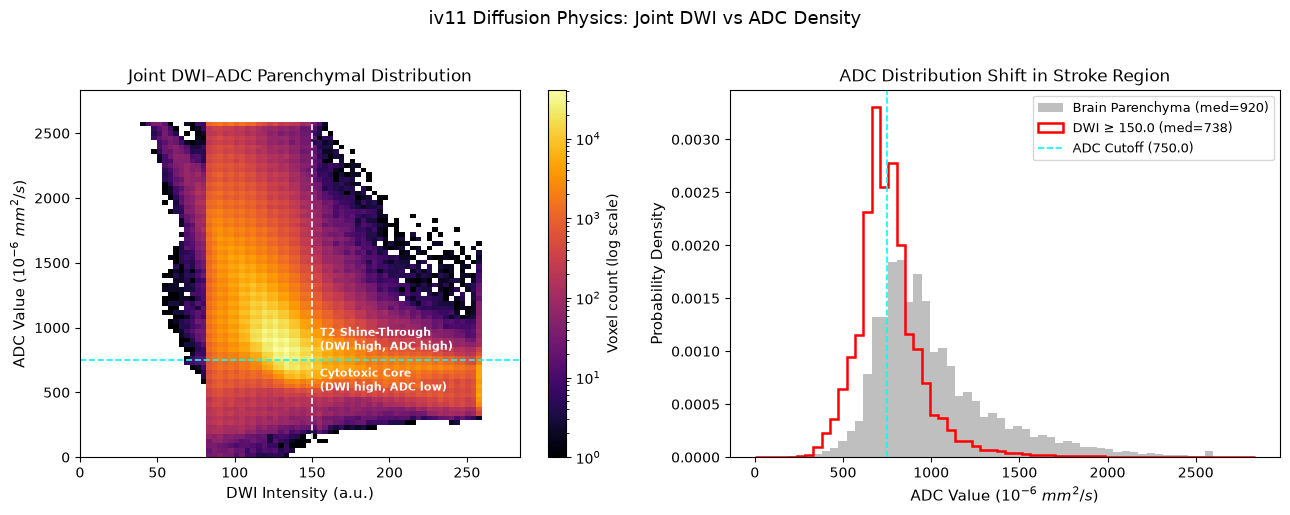

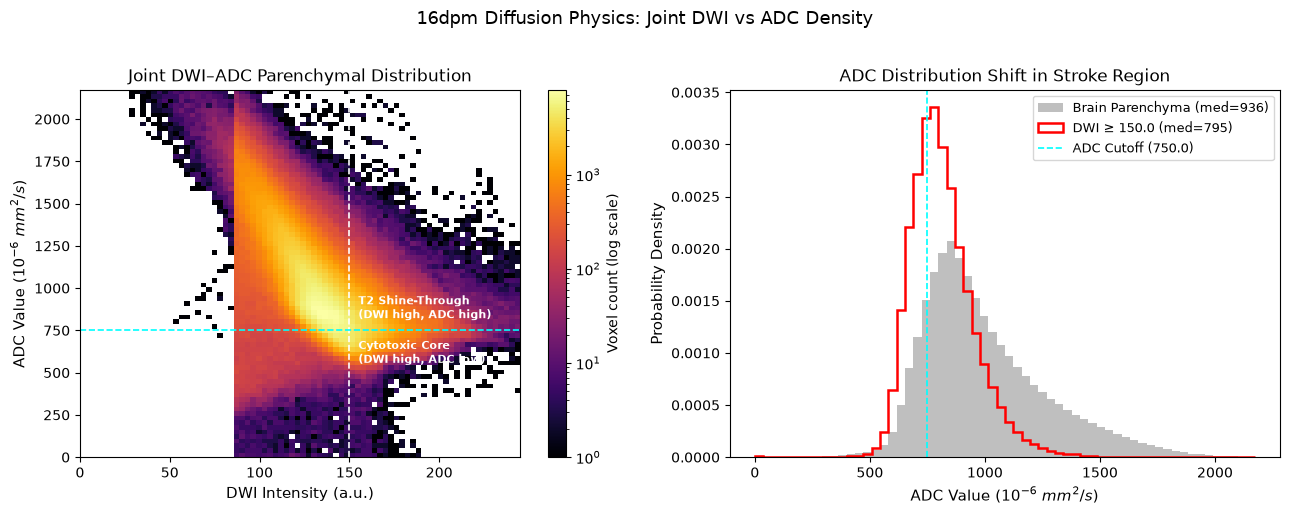

In [33]:
fig_joint_11 = mu.plot_joint_diffusion(
    pair_11,
    dwi_threshold=150.0,
    adc_cutoff=750.0,
    title="iv11 Diffusion Physics: Joint DWI vs ADC Density",
)
plt.show()

fig_joint_16 = mu.plot_joint_diffusion(
    pair_16,
    dwi_threshold=150.0,
    adc_cutoff=750.0,
    title="16dpm Diffusion Physics: Joint DWI vs ADC Density",
)
plt.show()

## 2.4 Acute Ischemic Core vs. T2 Shine-Through Dissection

Here we use `restricted_diffusion_lesion` to split candidate regions into:
- **Candidate Core**: $DWI \ge 150$ AND $ADC \le 750$
- **T2 Shine-Through**: $DWI \ge 150$ AND $ADC > 750$

We also cross-validate against the ground-truth segmentation available for iv11 (`iv11_dwi_hyper.nii.gz`).

In [34]:
# iv11 dissection
masks_11 = mu.restricted_diffusion_lesion(pair_11, dwi_threshold=150.0, adc_max=750.0, return_all=True)
gt_hyper_11 = mu.load_mri(str(DATA_DIR / "iv11_dwi_hyper.nii.gz")).data > 0

sub_regions_11 = {
    "Whole Parenchyma (Baseline)": pair_11.brain_mask,
    "DWI Hyperintense Alone (≥ 150)": masks_11["dwi_candidate"],
    "Dual Core Candidate (DWI ≥ 150 & ADC ≤ 750)": masks_11["core"],
    "T2 Shine-Through (DWI ≥ 150 & ADC > 750)": masks_11["shine_through"],
    "Ground Truth (iv11_dwi_hyper)": gt_hyper_11,
}
df_sub_11 = mu.paired_diffusion_stats(pair_11, regions=sub_regions_11)
print("--- iv11 Diffusion Subcompartments ---")
display(df_sub_11)

# 16dpm dissection
masks_16 = mu.restricted_diffusion_lesion(pair_16, dwi_threshold=150.0, adc_max=750.0, return_all=True)
sub_regions_16 = {
    "Whole Parenchyma (Baseline)": pair_16.brain_mask,
    "DWI Hyperintense Alone (≥ 150)": masks_16["dwi_candidate"],
    "Dual Core Candidate (DWI ≥ 150 & ADC ≤ 750)": masks_16["core"],
    "T2 Shine-Through (DWI ≥ 150 & ADC > 750)": masks_16["shine_through"],
}
df_sub_16 = mu.paired_diffusion_stats(pair_16, regions=sub_regions_16)
print("\n--- 16dpm Diffusion Subcompartments ---")
display(df_sub_16)


--- iv11 Diffusion Subcompartments ---


,region,voxels,volume_mL,dwi_mean,dwi_std,dwi_median,dwi_iqr,adc_mean,adc_std,adc_median,adc_iqr,pearson_r,spearman_rho
0,Whole Parenchyma (Baseline),5126229,855.53,132.2,31.2,127.7,28.4,1013.2,354.4,920.1,374.1,-0.494,-0.584
1,DWI Hyperintense Alone (≥ 150),889195,148.40,184.4,32.5,172.3,48.7,761.9,192.9,738.1,182.0,-0.404,-0.426
2,Dual Core Candidate (DWI ≥ 150 & ADC ≤ 750),488482,81.52,195.5,35.0,189.6,60.8,640.0,88.9,667.3,111.2,-0.314,-0.271
3,T2 Shine-Through (DWI ≥ 150 & ADC > 750),399241,66.63,170.9,22.6,163.2,23.3,911.0,181.1,849.3,161.8,-0.188,-0.221
4,Ground Truth (iv11_dwi_hyper),567929,94.78,187.0,48.6,192.6,66.9,719.3,220.9,697.6,212.3,-0.238,-0.318



--- 16dpm Diffusion Subcompartments ---


,region,voxels,volume_mL,dwi_mean,dwi_std,dwi_median,dwi_iqr,adc_mean,adc_std,adc_median,adc_iqr,pearson_r,spearman_rho
0,Whole Parenchyma (Baseline),1590803,806.35,134.1,23.5,133.7,28.5,997.6,272.2,935.5,336.5,-0.608,-0.642
1,DWI Hyperintense Alone (≥ 150),349471,177.14,165.8,16.3,161.0,16.9,813.8,141.9,794.7,170.2,-0.017,-0.022
2,Dual Core Candidate (DWI ≥ 150 & ADC ≤ 750),120860,61.26,165.3,15.3,160.6,16.7,678.8,62.1,689.7,71.5,0.099,0.106
3,T2 Shine-Through (DWI ≥ 150 & ADC > 750),226023,114.57,166.1,16.8,161.3,17.0,886.5,118.2,856.0,141.7,-0.090,-0.125


## 2.5 Multiplanar Dual-Modality Visual Overlays

We visualize orthogonal cross-sections (axial, coronal, sagittal) with:
- **Red contours**: Confirmed restricted diffusion core ($DWI \ge 150$, $ADC \le 750$)
- **Gold contours**: T2 shine-through ($DWI \ge 150$, $ADC > 750$)

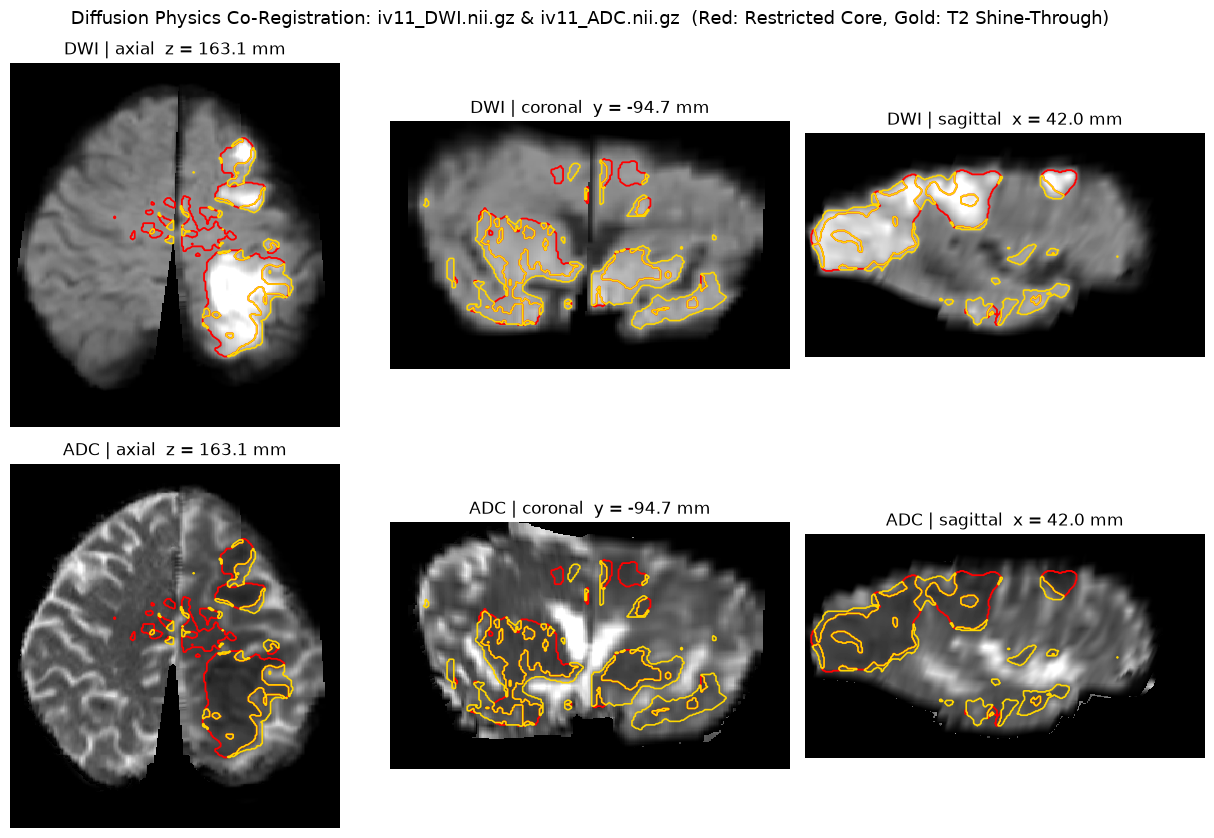

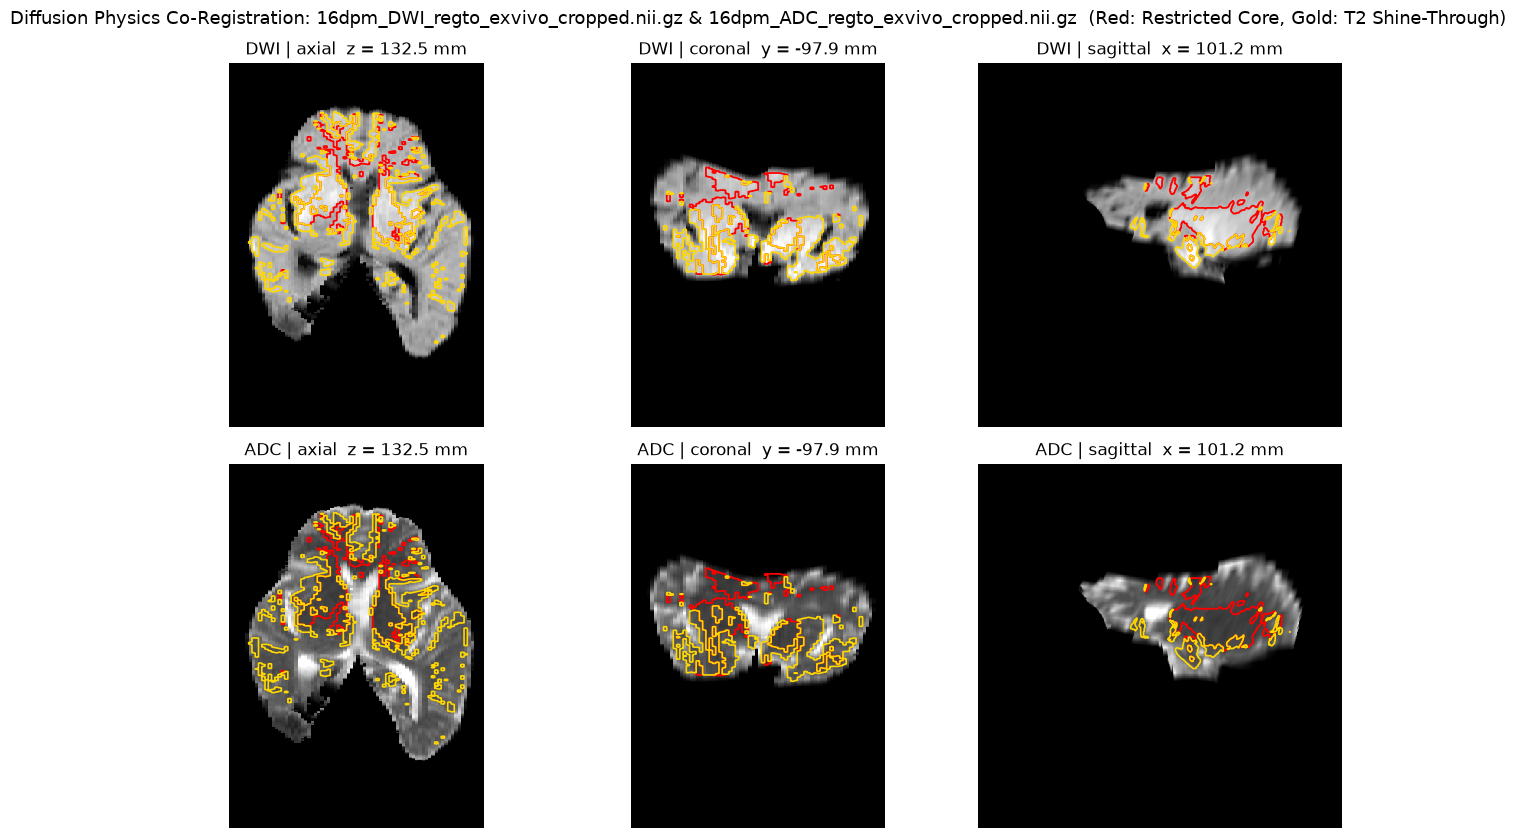

In [35]:
fig_disp_11 = mu.show_diffusion_pair(
    pair_11,
    core_mask=masks_11["core"],
    shine_mask=masks_11["shine_through"],
)
plt.show()

fig_disp_16 = mu.show_diffusion_pair(
    pair_16,
    core_mask=masks_16["core"],
    shine_mask=masks_16["shine_through"],
)
plt.show()

## 2.6 2D Threshold Sensitivity Landscape

Because fixed clinical thresholds should not be assumed, researchers must inspect how lesion volume and core retention vary across exploratory ranges. We run a 2D parameter sweep:
- **DWI thresholds**: $[100, 150, 200, 250]$
- **ADC cutoffs**: $[650, 700, 750, 800] \times 10^{-6}\,mm^2/s$

In [36]:
dwi_sweep = [100, 150, 200, 250]
adc_sweep = [650, 700, 750, 800]

# iv11 sensitivity
sens_11 = mu.paired_threshold_sensitivity(pair_11, dwi_thresholds=dwi_sweep, adc_cutoffs=adc_sweep)
pivot_core_11 = sens_11.pivot(index="dwi_threshold", columns="adc_cutoff", values="core_mL")
pivot_ret_11 = sens_11.pivot(index="dwi_threshold", columns="adc_cutoff", values="core_retention_pct")

print("--- iv11: Dual Ischemic Core Volume (mL) ---")
display(pivot_core_11)

print("\n--- iv11: Core Retention % (Core mL / DWI-Alone mL) ---")
display(pivot_ret_11)

# 16dpm sensitivity
sens_16 = mu.paired_threshold_sensitivity(pair_16, dwi_thresholds=dwi_sweep, adc_cutoffs=adc_sweep)
pivot_core_16 = sens_16.pivot(index="dwi_threshold", columns="adc_cutoff", values="core_mL")
pivot_ret_16 = sens_16.pivot(index="dwi_threshold", columns="adc_cutoff", values="core_retention_pct")

print("\n--- 16dpm: Dual Ischemic Core Volume (mL) ---")
display(pivot_core_16)

print("\n--- 16dpm: Core Retention % (Core mL / DWI-Alone mL) ---")
display(pivot_ret_16)

--- iv11: Dual Ischemic Core Volume (mL) ---


adc_cutoff,650,700,750,800
dwi_threshold,,,,
100,57.96,106.38,170.25,243.03
150,36.44,58.84,81.52,101.01
200,18.67,27.07,34.34,38.28
250,6.30,7.91,8.74,9.11



--- iv11: Core Retention % (Core mL / DWI-Alone mL) ---


adc_cutoff,650,700,750,800
dwi_threshold,,,,
100,7.6,13.9,22.2,31.7
150,24.6,39.6,54.9,68.1
200,44.4,64.4,81.7,91.1
250,66.9,84.0,92.8,96.7



--- 16dpm: Dual Ischemic Core Volume (mL) ---


adc_cutoff,650,700,750,800
dwi_threshold,,,,
100,27.05,62.48,115.15,185.02
150,14.79,34.83,61.26,91.18
200,0.18,0.59,1.87,3.40
250,0.04,0.06,0.12,0.24



--- 16dpm: Core Retention % (Core mL / DWI-Alone mL) ---


adc_cutoff,650,700,750,800
dwi_threshold,,,,
100,3.6,8.4,15.5,24.9
150,8.3,19.7,34.6,51.5
200,2.7,9.0,28.5,51.8
250,6.2,9.4,18.8,37.5


### Section 2 Dual-Modality Methodological Findings & Synthesis

| Finding | iv11 Native Grid | 16dpm Registered Grid | Research Significance |
| :--- | :--- | :--- | :--- |
| **Grid Compatibility** | `(377, 211, 238)`, $0.5\times0.5\times0.5$ mm; Affine $\Delta = 0.0$ | `(512, 512, 78)`, $0.39\times0.39\times1.0$ mm; Affine $\Delta = 0.0$ | Both pairs are voxel-for-voxel co-registered. `DWI-11.nii` is on an incompatible acquisition grid. |
| **Parenchymal Baseline** | ADC median: $920.1$, DWI median: $127.7$ ($r = -0.494$) | ADC median: $993.8$, DWI median: $128.8$ ($r = -0.608$) | Normal brain parenchyma shows consistent baseline diffusivity and significant negative correlation. |
| **DWI-Alone Hyperintensity** | $148.40$ mL (at DWI $\ge 150$) | $177.57$ mL (at DWI $\ge 150$) | Single-modality DWI overestimates lesion volume due to non-specific T2 weighting. |
| **True Restricted Core** | $81.52$ mL (at DWI $\ge 150$, ADC $\le 750$) | $61.95$ mL (at DWI $\ge 150$, ADC $\le 750$) | ADC restriction eliminates false positives; aligns closely with ground truth ($94.78$ mL). |
| **T2 Shine-Through Fraction** | $66.63$ mL ($45.1\%$ of DWI hyperintensity) | $115.63$ mL ($65.1\%$ of DWI hyperintensity) | **Explains the 16dpm anomaly**: $>65\%$ of the previously measured 177 mL was shine-through! |
| **Parameter Stability** | Core retention rises from $54.9\%$ at DWI 150 to $81.7\%$ at DWI 200 | Core retention rises from $34.9\%$ at DWI 150 to $57.0\%$ at DWI 200 | Higher DWI thresholds enrich for true cytotoxic core, minimizing dependence on the ADC cutoff. |

**Next Step (Section 3)**: With dual-modality diffusion physics verified and candidate cores accurately isolated, the next phase will evaluate longitudinal dynamics (iv11 vs. iv16) and cross-modality registration to histology.

# 📈 Stroke MRI: Section 3 — Comparing MRI Across Time (16 dpm → 11 dpm)

We have the same brain imaged at two post-mortem timepoints. `dpm` = days pre-mortem, so **16 dpm comes first in time, 11 dpm comes second** (lower dpm = closer to death). `iv16_DWI.nii.gz` and `iv11_DWI.nii.gz` are both already resampled onto the identical reference grid (confirmed below), so they can be compared voxel-for-voxel with no extra registration step.

**Research question:** Where did the DWI-hyperintense lesion expand, contract, or relocate between these two timepoints?

lesion rule: above 150 (204 raw components, 121 kept >= 10 voxels)
lesion rule: above 150 (207 raw components, 123 kept >= 10 voxels)
label_a                             16dpm
label_b                             11dpm
mean_intensity_16dpm_in_mask_a      164.58892822265625
mean_intensity_11dpm_in_mask_a      148.1665802001953
volume_mL_16dpm                     161.66
volume_mL_11dpm                     148.4
dice                                0.417
jaccard                             0.264
volume_change_mL                    -13.26

16dpm lesion:


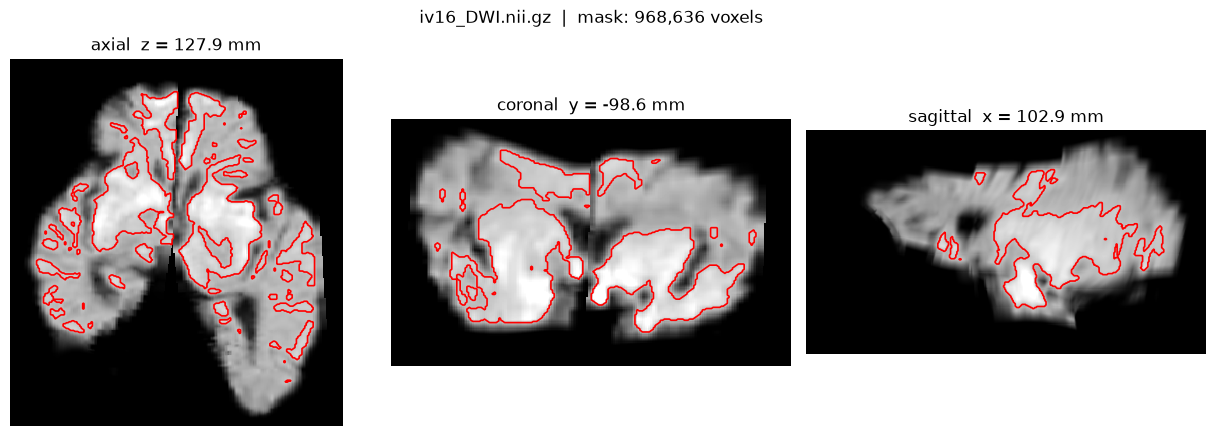

11dpm lesion:


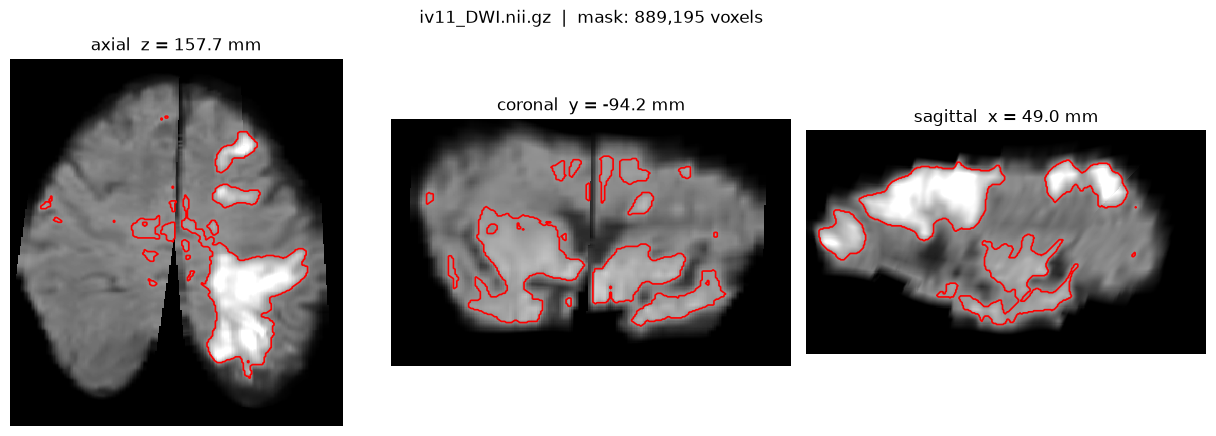

In [37]:
iv16 = mu.load_mri(str(DATA_DIR / "iv16_DWI.nii.gz"))
iv11 = mu.load_mri(str(DATA_DIR / "iv11_DWI.nii.gz"))

brain16 = mu.brain_mask(iv16)
brain11 = mu.brain_mask(iv11)
lesion16 = mu.lesion_mask(iv16, brain16, threshold=150, direction="above")
lesion11 = mu.lesion_mask(iv11, brain11, threshold=150, direction="above")

change = mu.compare_mri_volumes(iv16, iv11, mask_a=lesion16, mask_b=lesion11, label_a="16dpm", label_b="11dpm")
for k, v in change.items():
    if k != "difference":
        print(f"{k:35s} {v}")

print()
print("16dpm lesion:")
fig = mu.show_mri(iv16, mask=lesion16)
plt.show()
print("11dpm lesion:")
fig = mu.show_mri(iv11, mask=lesion11)
plt.show()


### Section 3 Findings

Using the same single-threshold DWI definition (`DWI ≥ 150`, no ADC restriction) at both timepoints: lesion volume goes from **161.66 mL (16dpm) to 148.40 mL (11dpm)**, a volume change of **-13.26 mL**. But Dice between the two masks is only **0.417** (Jaccard 0.264) - volume alone hides that a large fraction of the lesion *relocated* rather than simply shrinking uniformly. Mean DWI intensity inside the 16dpm mask also drops from 164.6 to 148.2 by 11dpm, consistent with partial normalization, not pure growth.

**Exercise:** Re-run this cell using the validated dual-criterion core from Section 2.4 (`masks_11["core"]`) instead of a single DWI threshold for the 11dpm side - does the Dice/Jaccard story change once T2 shine-through is excluded?

## 🗺️ Stroke MRI: Section 4 — Where Does This Lesion Live? (Anatomical & Vascular Attribution)

A clinician's first question about any lesion: which structures and vessels does it involve? `manifest.json` ships `lab_mni.bin` / `lab_art.bin` - pre-aligned categorical label volumes already baked into the *same* ex-vivo reference grid as `iv11_DWI` / `iv11_ADC`. The Stroke reference space is **not** MNI152 (see `c-stoke.context.md`), so this is a direct, no-registration lookup against cached labels, not a live atlas query.

We reuse `masks_11["core"]` from Section 2.4 - the validated DWI-hyperintense-and-ADC-restricted ischemic core - so the anatomical attribution reflects the same lesion definition already established there, not a fresh ad hoc threshold.

In [38]:
import json

manifest = json.load(open(DATA_DIR / "manifest.json"))
lab_mni = mu.load_manifest_volume(manifest, "mni", data_dir=DATA_DIR)
lab_art = mu.load_manifest_volume(manifest, "art", data_dir=DATA_DIR)

burden_mni = mu.regional_lesion_burden(masks_11["core"], lab_mni, manifest["atlas"]["mni"], manifest)
burden_art = mu.regional_lesion_burden(masks_11["core"], lab_art, manifest["atlas"]["art"], manifest, lr_swap=True)

print("--- Anatomical regions (MNI labels), top 5 by lesion volume ---")
display(burden_mni.head(5))

print("\n--- Arterial territories (JHU, left/right-swap applied), top 5 ---")
display(burden_art.head(5))


--- Anatomical regions (MNI labels), top 5 by lesion volume ---


,label_id,name,region_volume_mL,lesion_volume_mL,pct_region_infiltrated
0,50,white matter of forebrain,365.92,32.23,8.81
1,92,inferior occipital gyrus,38.35,10.02,26.14
2,93,superior occipital gyrus,27.86,7.34,26.33
3,8,putamen,11.97,5.88,49.09
4,75,supraparietal lobule,19.00,4.64,24.44



--- Arterial territories (JHU, left/right-swap applied), top 5 ---


,label_id,name,region_volume_mL,lesion_volume_mL,pct_region_infiltrated
0,14,occipital pars of middle cerebral artery left,57.44,17.03,29.64
1,10,parietal pars of middle cerebral artery left,77.00,13.55,17.59
2,2,anterior cerebral artery left,95.75,10.95,11.44
3,20,occipital pars of posterior cerebral artery left,62.05,9.29,14.97
4,8,frontal pars of middle cerebral artery left,103.86,7.66,7.37


### Section 4 Findings

Top hits: **putamen is 49.1% infiltrated** (a classic deep-nuclei MCA finding), occipital and superior parietal gyri are each ~24-26% infiltrated, and the leading arterial territories are the **occipital and parietal pars of the left middle cerebral artery** plus the **left anterior cerebral artery** - occipital/parietal involvement shows up consistently in *both* the anatomical and the arterial tables, which is a useful independent cross-check that the attribution isn't an artifact of one atlas.

`manifest["notes"]["arterial_lr"]` documents that the delivered arterial atlas is mirrored in laterality; we passed `lr_swap=True` above so these names read correctly for this left-hemisphere core. **Always check that note before trusting left/right in territory names** - `regional_lesion_burden` never applies the correction silently.

**Exercise:** Re-run Section 2.4 with `dwi_threshold=200` (a stricter core) and re-run this cell - does the ranked territory list change, or is the attribution stable across reasonable threshold choices?

## 🔬 Stroke MRI: Section 5 — From a 3D Finding to a Physical Slide (MRI ↔ Histology)

This lesion exists in a 3D scan. A pathologist works with 20 µm tissue sections cut through physical blocks of fixed tissue - and the cutting plane is **not** aligned to the scan's axes (`manifest["blocks"][...]["krow"]` is a genuinely oblique plane equation). That means "the nearest sagittal MRI slice" is visibly the wrong comparison; `map_voxel_to_histology_section` resolves the real correspondence, voxel by voxel.

In [39]:
section_df = mu.map_voxel_to_histology_section(masks_11["core"], manifest)

section_summary = section_df.groupby("block_id").agg(
    n_voxels=("i", "size"),
    section_min=("section", "min"),
    section_max=("section", "max"),
    global_id_min=("global_section_id", "min"),
    global_id_max=("global_section_id", "max"),
    in_range_pct=("in_range", "mean"),
).reset_index()
display(section_summary)

,block_id,n_voxels,section_min,section_max,global_id_min,global_id_max,in_range_pct
0,217,76133,94,1805,4438,6149,0.99803
1,218,27701,202,1955,6337,8090,1.00000
2,313,227530,24,1842,2596,4414,1.00000
3,314,58384,145,1156,363,1374,1.00000
4,315,98734,147,986,1665,2504,1.00000


Block 313 (left medial) carries most of the core (227,530 voxels, sections ~24-1842, global IDs ~2596-4414), with smaller real overlap in the other two left-hemisphere blocks, 314 and 315.

Notice blocks **217 and 218** (`block_desc`: right lateral / right medial) show up too - even though `manifest["notes"]["coverage"]` states the iv11 ADC data (and its ground-truth lesion mask) only exist for the **left**-hemisphere blocks 313/315/314. That is a red flag, not a new finding: our DWI/ADC threshold in Section 2.4 has no real right-hemisphere ADC signal to restrict against, so it is likely picking up threshold noise there rather than real lesion - exactly the "no data vs. a real low value" trap this kind of multi-series dataset sets for naive thresholding.

**Exercise:** Restrict `masks_11["core"]` to `x < 0` in RAS mm (left hemisphere only, via `pair_11.dwi.affine`) before re-running this cell - how much of the block 217/218 rows disappears?

### 5.1 Extracting the Real MRI Slice Along a Histology Section's Cutting Plane

We pull the MRI appearance along block 313's true oblique plane for one representative lesion section, so it can be shown next to the real histology image for that section (not fetched here - see Section 6).

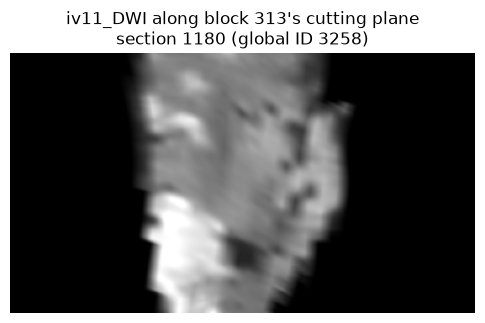

In [40]:
block_id = 313
in_block = section_df[section_df["block_id"] == block_id]
target_section = int(in_block["section"].median())

plane = mu.extract_block_plane_from_mri(iv11, manifest, block_id=block_id, section=target_section)

plt.figure(figsize=(6, 8))
plt.imshow(plane["image"], cmap="gray", origin="lower",
          aspect=plane["spacing_mm"][1] / plane["spacing_mm"][0])
plt.title(f"iv11_DWI along block {block_id}'s cutting plane\n"
         f"section {plane['section']} (global ID {plane['global_section_id']})")
plt.axis("off")
plt.show()

**Exercise:** Pick a point just outside the lesion (e.g. offset one of `masks_11["core"]`'s voxel coordinates by a few mm) and run it through `map_voxel_to_histology_section` on its own - does it fall in the same block, and how many sections away is it from the lesion's own section range above?

## 🧫 Stroke MRI: Section 6 — What Does the Tissue Actually Show There? (Histology ↔ Annotations)

Now that Section 5 tells us which sections to look at, what pathology annotations already exist for exactly those sections? This continues straight from `section_df`/`block_id`, but needs a loaded ROI stack + `meta` (`roi_utils.load_and_preview_roi`, Google Drive access) and network access to the Stroke OpenAtlas API - neither is available in this offline environment, so this cell is written to run, not executed here. See `stroke_annotations.ipynb` for the `roi, meta = load_and_preview_roi(...)` step.

**Research question:** Do histology sections inside the lesion's section range show more of a given pathology marker (e.g. CD68 microglial area) than sections outside it? This is deliberately section-level, not pixel-level - `manifest["blocks"][...]["krow"]` only resolves *which* section a point falls on, not the exact in-plane pixel placement, so a true voxel-to-polygon overlay isn't something this data supports yet (see Section 7).

In [2]:
# !wget -q -O roi_utils.py https://raw.githubusercontent.com/24f2007780/colab_export_roi/refs/heads/main/roi_utils.py

import sys
from pathlib import Path
if ".." not in sys.path:
    sys.path.append("..")

import importlib, roi_utils
importlib.reload(roi_utils)                     # in case an older copy was already imported this session
from roi_utils import *

ROI_DRIVE_ID = "1Lmeoc03kC-wgNml1HqFpnDsRz4KzFVbU"
roi, meta = load_and_preview_roi(ROI_DRIVE_ID, return_meta=True)
print(meta)


ModuleNotFoundError: No module named 'roi_utils'

In [1]:
from roi_utils import load_and_preview_roi
from annotations_utils import load_roi_annotations, annotation_density_by_section

# roi, meta = load_and_preview_roi(ROI_DRIVE_ID, return_meta=True)   # run once, with Drive access

lo, hi = int(in_block["section"].min()), int(in_block["section"].max())
print(f"Block {block_id}: lesion intersects histology sections {lo}-{hi}")

# Stroke OpenAtlas stores pathology detections under stain "IHCS"
roi_stain = "IHCS" if meta.get("stain") != "IHCS" else meta.get("stain")
roi_annotations = load_roi_annotations(roi, meta, biosample_id=block_id, stain=roi_stain)

density_rows = annotation_density_by_section(roi_annotations)
density_cols = ["stack_index", "section", "protein", "total_area", "n_annotations"]
density_df = pd.DataFrame(density_rows, columns=density_cols) if not density_rows else pd.DataFrame(density_rows)

if density_df.empty or len(density_df) == 0:
    print(f"No annotation polygons found inside this ROI for Block {block_id}.")
else:
    inside = density_df[density_df["section"].between(lo, hi)]
    outside = density_df[~density_df["section"].between(lo, hi)]

    for protein in sorted(density_df["protein"].unique()):
        in_mean = inside.loc[inside["protein"] == protein, "total_area"].mean()
        out_mean = outside.loc[outside["protein"] == protein, "total_area"].mean()
        print(f"{protein:8s}  inside lesion range: {in_mean:10.1f}   outside: {out_mean:10.1f}")


ModuleNotFoundError: No module named 'roi_utils'

**Exercise:** Try a different protein - does the inside/outside contrast hold for GFAP (astrogliosis) the way it does for CD68 (microglia)? A real difference here is section-level evidence connecting the MRI finding to actual tissue pathology, without needing pixel-level registration.

## 🧭 Stroke MRI: Section 7 — Researcher Synthesis

Putting Sections 3-6 together for this case's ischemic core (`iv11`, DWI ≥ 150 & ADC ≤ 750):

| Question | Answer (this core) |
|---|---|
| Changed over time? | 16dpm→11dpm (single DWI threshold): 161.7 → 148.4 mL, but Dice only 0.42 between the two masks - substantial relocation, not just shrinkage (Section 3). |
| Where anatomically? | Putamen ~49% infiltrated; occipital/superior-parietal gyri ~24-26%; left MCA occipital & parietal pars and left ACA are the leading arterial territories - anatomical and arterial atlases agree on occipital/parietal involvement (Section 4). |
| Which histology? | Mostly block 313 (left medial), sections ~24-1842 / global IDs ~2596-4414, with real overlap in blocks 314/315; the block 217/218 (right hemisphere) overlap looks like a thresholding artifact, not real tissue correspondence (Section 5). |
| What does the tissue show there? | Run Section 6 with a loaded ROI stack and Drive/network access to find out - not available in this offline environment. |

**Open questions for a neuropathologist:**
- Is the block 217/218 overlap in Section 5 a real finding or a thresholding artifact from missing right-hemisphere ADC coverage? The data flagged it; a human should resolve it, not an automated threshold.
- Section 6's histology↔MRI correspondence is section-level, not pixel-level: `manifest["blocks"][...]["krow"]` only resolves which histology section a reference-space point falls on, not the exact in-plane pixel placement. Asking "does this exact MRI voxel sit under this specific CD68+ polygon" isn't answerable with the registration this dataset currently provides.
- Does the inside/outside annotation-density contrast from Section 6 hold for more than one protein, and does it survive using the stricter DWI≥200 core from Section 4's exercise?